# Fusion ensemble inference: where the time goes, and what the speed work bought

`FusionEnsemble.predict(smiles, context=ctx)` is the call a screening or reinforcement-learning
loop makes hundreds of thousands of times: one fixed biological context, a stream of molecules.
This notebook measures that path and compares it with numbers captured from the **unchanged
package** (`baseline_*.csv`, stamped with the commit they came from).

What changed in the package: float32 throughout (with a float64 retry for a factorisation float32
cannot do), no standardisation of any block, one canonical context shared by every member, and
six redundancies removed from the inference path (R1-R7 below).

Accuracy is **measured and reported, not gated**: the ensembles on disk were fitted under the old
numerics and will be retrained with hyper-parameter optimisation, so a degradation is expected.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # torch + xgboost libomp clash on macOS

import copy
import gc
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "notebooks"))
import ensemble_inference_bench as bench
from tackai.fusion.data import FusionData
from tackai.fusion.ensemble import FusionEnsemble

RESULTS = REPO / "notebooks" / "ensemble_inference_speed_results"
ENSEMBLES = REPO / "ensembles"
TASKS = [t for t in os.environ.get("INFER_TASKS", "dmax,pdc50,activity").split(",") if t]
POOL, REPEAT = 1024, int(os.environ.get("INFER_REPEAT", "5"))
PATH_COLOR = {"context+std": "#2a6fdb", "context": "#4aa3c7", "records": "#d9822b",
              "matrix": "#6b9a3a"}
STAGES = ["encode", "featurise", "transform", "model", "aggregate", "other"]
STAGE_COLOR = dict(zip(STAGES, ["#a07fd1", "#d9822b", "#4aa3c7", "#2a6fdb", "#6b9a3a", "#c9cbcf"]))

NEED = ["scaling", "breakdown", "redundancy", "setup", "featurise", "heldout"]
missing = [f"baseline_{n}.csv" for n in NEED if not (RESULTS / f"baseline_{n}.csv").exists()]
if not (RESULTS / "baseline_predictions.npz").exists():
    missing.append("baseline_predictions.npz")
assert not missing, f"capture the baseline at the pre-change commit first: {missing}"
print(f"torch {torch.__version__} | numpy {np.__version__} | tasks {TASKS} | repeat {REPEAT}")
print("package now at", bench.stamp())
print(f"machine: {os.cpu_count()} cores, load average {os.getloadavg()[0]:.1f} (1 min) -- timings are taken on a shared machine; ratios of medians, and minima for the member sweep")

torch 2.11.0 | numpy 2.5.3 | tasks ['dmax', 'pdc50', 'activity'] | repeat 5
package now at {'commit': 'cdfc4c4', 'dirty': True}
machine: 11 cores, load average 6.5 (1 min) -- timings are taken on a shared machine; ratios of medians, and minima for the member sweep


## 1. Before: the unchanged code

Everything in this section is read from `baseline_*.csv`, written by `ensemble_inference_bench.py`
before any of the speed work landed.

In [2]:
def read(label, name):
    frame = pd.read_csv(RESULTS / f"{label}_{name}.csv")
    return frame[frame["task"].isin(TASKS)] if "task" in frame else frame


base = {name: read("baseline", name) for name in NEED}
print("baseline measured at", base["scaling"][["commit", "dirty"]].drop_duplicates()
      .to_dict("records"))
print(f"cold featurisation: {base['featurise'].iloc[0, 0] * 1e3:.1f} ms per molecule "
      "(not part of any number below: the featuriser memoises)")
print("\nmicroseconds per molecule at batch 256")
display(base["scaling"].query("batch == 256")
        .pivot(index="task", columns="path", values="us_per_mol").round(1))
print("context set-up (ms) and training rows per task")
display(base["setup"].assign(context_setup_ms=lambda f: f["context_setup_s"] * 1e3)
        [["task", "members", "n_train", "context_setup_ms"]].round(2))

baseline measured at [{'commit': '26452f3', 'dirty': True}]
cold featurisation: 22.5 ms per molecule (not part of any number below: the featuriser memoises)

microseconds per molecule at batch 256


path,context,context+std,matrix,records
task,,,,
activity,487.1,837.2,1196.6,1225.7
dmax,462.9,602.7,1064.4,1037.3
pdc50,848.8,1296.8,1908.3,2038.9


context set-up (ms) and training rows per task


,task,members,n_train,context_setup_ms
0,dmax,5,2627,6.47
1,pdc50,5,4488,9.35
2,activity,5,2870,5.88


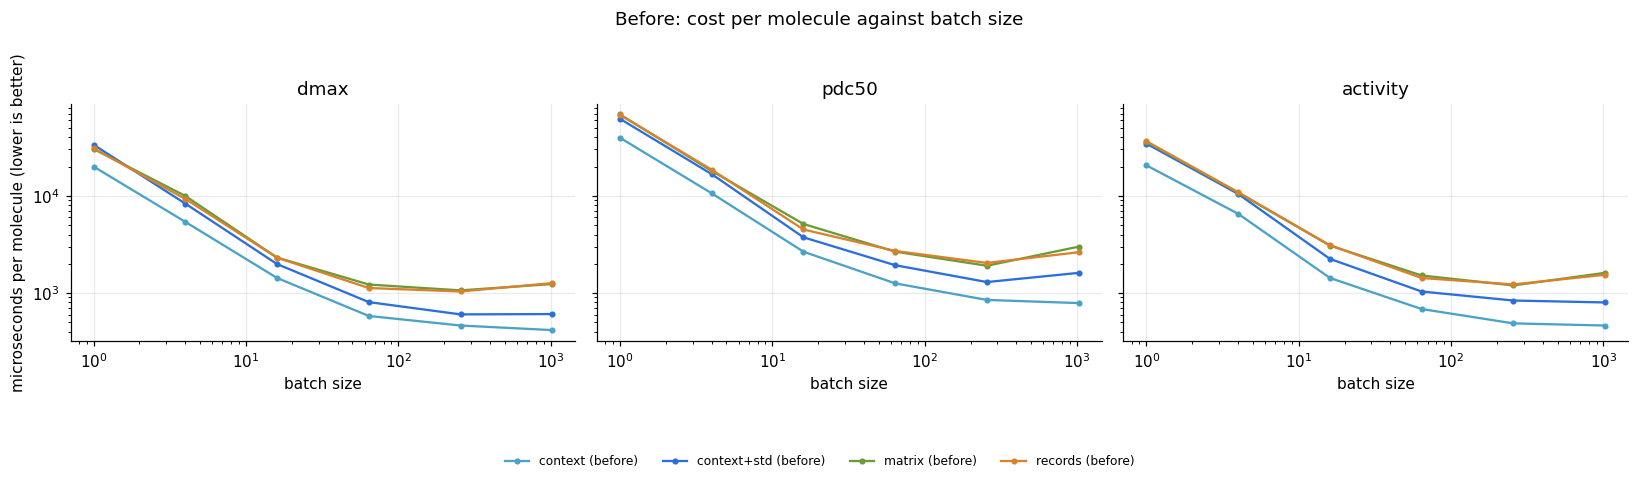

In [3]:
def plot_scaling(series, fname, title):
    """series: (label, frame, linestyle) triples; one panel per task, one line per path."""
    fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 4.3), sharey=True,
                             squeeze=False)
    for ax, task in zip(axes[0], TASKS):
        for label, frame, style in series:
            for path, g in frame[frame["task"] == task].groupby("path"):
                ax.plot(g["batch"], g["us_per_mol"], style, color=PATH_COLOR[path], marker="o",
                        ms=3, label=f"{path} ({label})")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(task)
        ax.set_xlabel("batch size")
    axes[0][0].set_ylabel("microseconds per molecule (lower is better)")
    handles, labels = axes[0][-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0.14, 1, 0.94))
    fig.savefig(RESULTS / fname, dpi=130)
    plt.show()


plot_scaling([("before", base["scaling"], "-")], "01_before_scaling.png",
             "Before: cost per molecule against batch size")

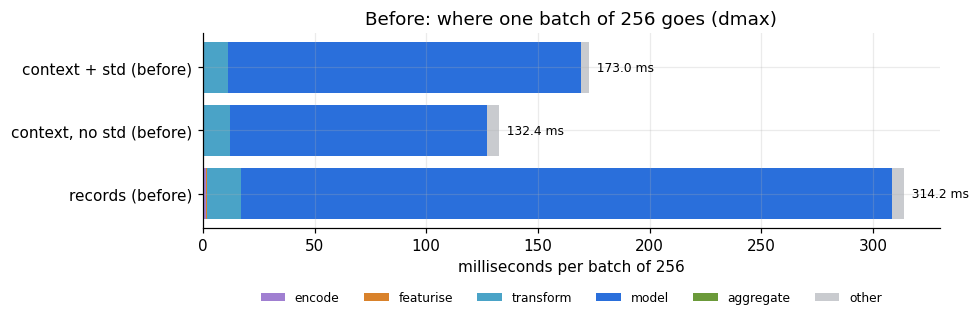

In [4]:
def plot_breakdown(frames, task, fname, title):
    """Stacked horizontal bars of exclusive time per stage; frames: label -> breakdown frame."""
    rows = [(label, path) for label in frames for path in ("context", "context_nostd", "records")]
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(rows) + 1.6))
    for y, (label, path) in enumerate(rows):
        part = frames[label].query("task == @task and path == @path").set_index("stage")["seconds"]
        left = 0.0
        for stage in STAGES:
            value = part.get(stage, 0.0) * 1e3
            ax.barh(y, value, left=left, color=STAGE_COLOR[stage],
                    label=stage if y == 0 else None)
            left += value
        ax.text(left, y, f"  {left:.1f} ms", va="center", fontsize=8)
    names = {"context": "context + std", "context_nostd": "context, no std", "records": "records"}
    ax.set_yticks(range(len(rows)), [f"{names[p]} ({l})" for l, p in rows])
    ax.invert_yaxis()
    ax.set_xlabel("milliseconds per batch of 256")
    ax.set_title(title)
    ax.legend(ncol=6, fontsize=8, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.45))
    fig.tight_layout()
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches="tight")
    plt.show()


plot_breakdown({"before": base["breakdown"]}, TASKS[0], "02_before_breakdown.png",
               f"Before: where one batch of 256 goes ({TASKS[0]})")

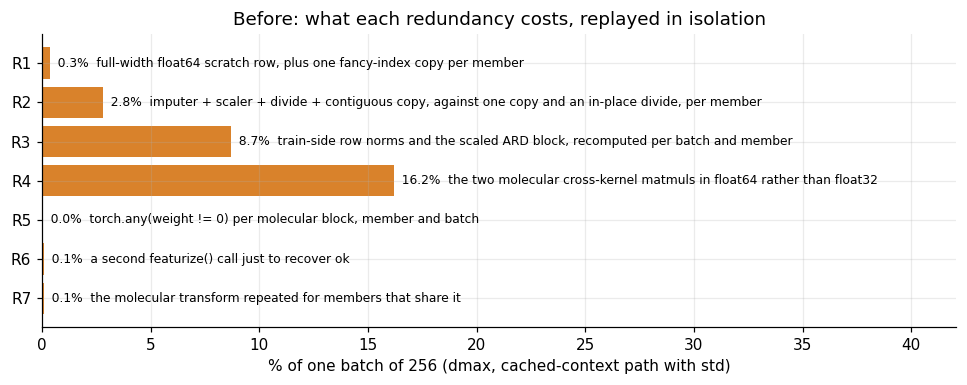

,item,what,seconds,share_of_predict
0,R1,"full-width float64 scratch row, plus one fancy...",0.00057,0.00344
1,R2,"imputer + scaler + divide + contiguous copy, a...",0.00467,0.02805
2,R3,"train-side row norms and the scaled ARD block,...",0.01444,0.08683
3,R4,the two molecular cross-kernel matmuls in floa...,0.02692,0.16183
4,R5,"torch.any(weight != 0) per molecular block, me...",0.00005,0.00030
5,R6,a second featurize() call just to recover ok,0.00015,0.00092
6,R7,the molecular transform repeated for members t...,0.00016,0.00097


In [5]:
red = base["redundancy"][base["redundancy"]["task"] == TASKS[0]]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(red["item"], red["share_of_predict"] * 100, color="#d9822b")
for y, (share, what) in enumerate(zip(red["share_of_predict"] * 100, red["what"])):
    ax.text(share, y, f"  {share:.1f}%  {what}", va="center", fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, max(red["share_of_predict"] * 100) * 2.6)
ax.set_xlabel(f"% of one batch of 256 ({TASKS[0]}, cached-context path with std)")
ax.set_title("Before: what each redundancy costs, replayed in isolation")
fig.tight_layout()
fig.savefig(RESULTS / "03_before_redundancy.png", dpi=130)
plt.show()
display(red[["item", "what", "seconds", "share_of_predict"]].round(5))

## 2. After: four configurations, so each change gets its own number

The saved ensembles are float64 with per-member context preprocessors. They are served here as

| | precision | context |
|---|---|---|
| **A** | float64 | per member (`shared_context=False`) — the old numerics on the new code: *redundancy removal only* |
| **B** | float64 | shared |
| **C** | float32 | per member |
| **D** | float32 | shared — the new defaults |

A and B run first; `astype("float32")` then re-conditions the same members in place for C and D.

In [6]:
data = FusionData.from_csv(bench.DEV_FILES)
record = bench.context_record(data)
pool = bench.smiles_pool(data, POOL)
base_pred = np.load(RESULTS / "baseline_predictions.npz")
assert list(base_pred["smiles"]) == pool[:256], "baseline pool differs from this run's pool"

CONFIGS = {"A": "f64 / per-member ctx", "B": "f64 / shared ctx",
           "C": "f32 / per-member ctx", "D": "f32 / shared ctx"}
final, sweeps, shifts, heldout, promoted = {}, [], [], [], []

for task in TASKS:
    stored = FusionEnsemble.from_pretrained(ENSEMBLES / f"fusion_{task}", data=data,
                                            shared_context=False)
    members = stored.members
    for name, cast, shared in (("A", None, False), ("B", None, True),
                               ("C", "float32", False), ("D", None, True)):
        if cast:
            FusionEnsemble(members, data, task, shared_context=False).astype(cast)
        ens = FusionEnsemble(members, data, task, shared_context=shared)
        sweeps.append(bench.sweep_paths(ens, record, pool, repeat=REPEAT)
                      .assign(task=task, config=name))
        pred = ens.predict(pool[:256], context=ens.transform_context(record))
        b_mean, b_std = base_pred[f"{task}_mean"], base_pred[f"{task}_std"]
        spread = base_pred[f"{task}_members"].std(axis=0).mean()
        shifts.append({"task": task, "config": name,
                       "corr": np.corrcoef(b_mean, pred.mean)[0, 1],
                       "mean_abs_shift": np.abs(pred.mean - b_mean).mean(),
                       "max_abs_shift": np.abs(pred.mean - b_mean).max(),
                       "baseline_member_spread": spread,
                       "std_ratio": float(np.median(pred.std / np.maximum(b_std, 1e-12)))})
        heldout.append({"task": task, "config": name,
                        "score": bench.heldout_score(ens, data, task)})
        promoted.append({"task": task, "config": name, "promoted_members": sum(ens.promoted),
                         "members": len(ens.members)})
        print(f"{task} {name} ({CONFIGS[name]}) done")
    final[task] = ens                       # config D
    del stored
    gc.collect()

sweeps = pd.concat(sweeps, ignore_index=True)
sweeps.to_csv(RESULTS / "configs_scaling.csv", index=False)

dmax A (f64 / per-member ctx) done


dmax B (f64 / shared ctx) done


dmax C (f32 / per-member ctx) done


dmax D (f32 / shared ctx) done


pdc50 A (f64 / per-member ctx) done


...

pdc50 D (f32 / shared ctx) done


activity A (f64 / per-member ctx) done


activity B (f64 / shared ctx) done


activity C (f32 / per-member ctx) done


activity D (f32 / shared ctx) done


after measured at [{'commit': 'cdfc4c4', 'dirty': True}]


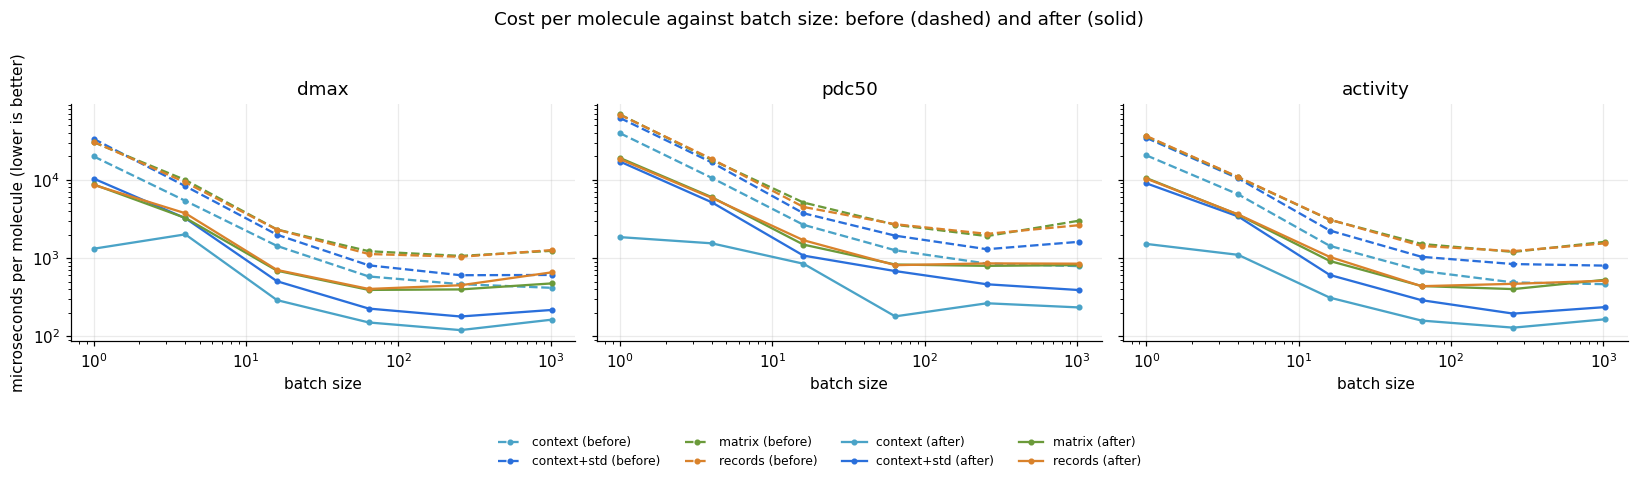

In [7]:
# The same capture the baseline used, run on the new defaults (config D), so the overlay
# compares like with like.
bench.capture_baseline(final, data, RESULTS, label="after", pool_size=POOL, repeat=REPEAT)
after = {name: read("after", name) for name in NEED}
print("after measured at", after["scaling"][["commit", "dirty"]].drop_duplicates()
      .to_dict("records"))
plot_scaling([("before", base["scaling"], "--"), ("after", after["scaling"], "-")],
             "04_before_after_scaling.png", "Cost per molecule against batch size: before (dashed) "
             "and after (solid)")

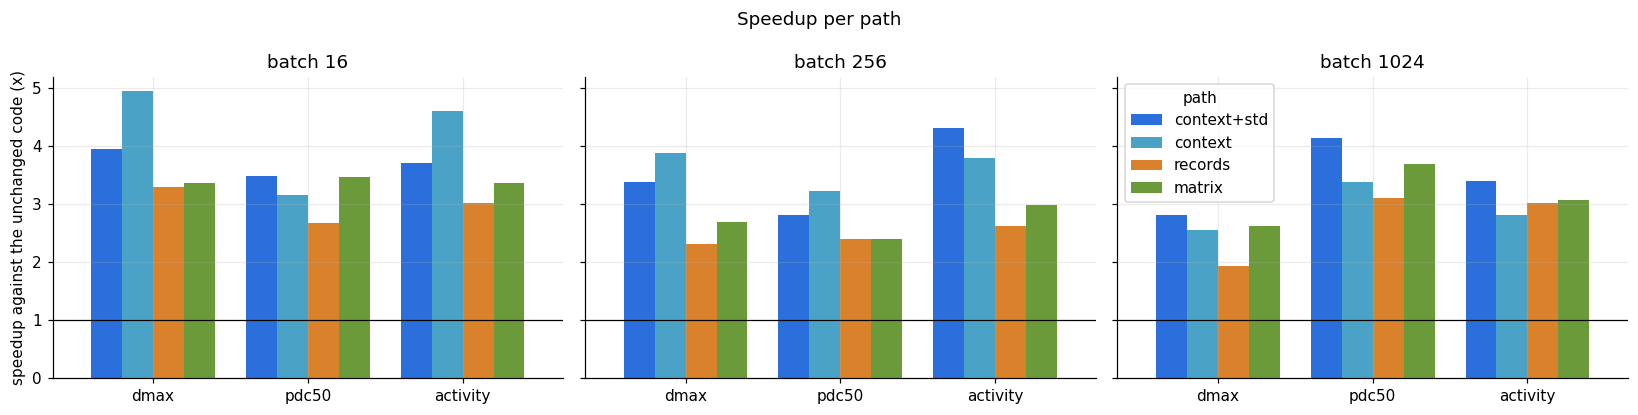

path,context,context+std,matrix,records
task,,,,
activity,3.79,4.31,2.99,2.62
dmax,3.87,3.38,2.69,2.31
pdc50,3.22,2.81,2.40,2.39


In [8]:
def speedups(batch):
    key = ["task", "path"]
    b = base["scaling"].query("batch == @batch").set_index(key)["us_per_mol"]
    a = after["scaling"].query("batch == @batch").set_index(key)["us_per_mol"]
    return (b / a).rename("speedup").reset_index()


batches = [16, 256, 1024]
fig, axes = plt.subplots(1, len(batches), figsize=(5 * len(batches), 3.8), sharey=True)
for ax, batch in zip(axes, batches):
    table = speedups(batch).pivot(index="task", columns="path", values="speedup")
    table = table.reindex(TASKS)[list(PATH_COLOR)]
    table.plot.bar(ax=ax, color=list(PATH_COLOR.values()), width=0.8, legend=batch == batches[-1])
    ax.axhline(1.0, color="k", lw=0.8)
    ax.set_title(f"batch {batch}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("speedup against the unchanged code (x)")
fig.suptitle("Speedup per path")
fig.tight_layout()
fig.savefig(RESULTS / "05_speedup.png", dpi=130)
plt.show()
display(speedups(256).pivot(index="task", columns="path", values="speedup").round(2))

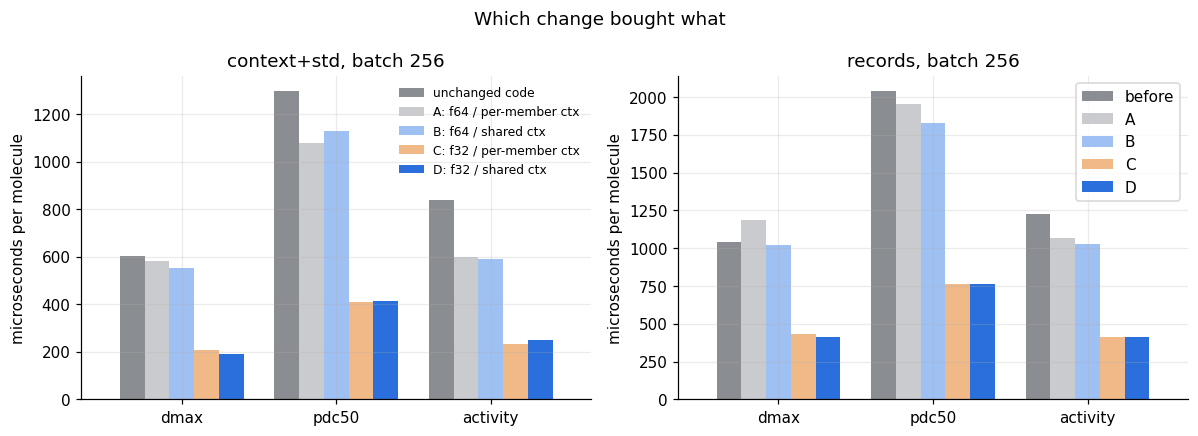

,path,task,before,A,B,C,D
0,context+std,dmax,602.7,581.7,552.8,205.8,189.5
1,context+std,pdc50,1296.8,1079.3,1127.0,411.1,415.4
2,context+std,activity,837.2,596.8,590.1,232.2,248.8
3,records,dmax,1037.3,1185.1,1020.8,432.7,414.6
4,records,pdc50,2038.9,1955.5,1827.2,759.6,764.5
5,records,activity,1225.7,1063.8,1027.8,410.7,412.8


In [9]:
# Attribution at batch 256: unchanged code, then A -> B -> C -> D on the new code.
rows = []
for path in ("context+std", "records"):
    for task in TASKS:
        row = {"path": path, "task": task,
               "before": base["scaling"].query("task == @task and path == @path and batch == 256")
               ["us_per_mol"].iloc[0]}
        for name in CONFIGS:
            row[name] = sweeps.query("task == @task and path == @path and batch == 256 "
                                     "and config == @name")["us_per_mol"].iloc[0]
        rows.append(row)
attr = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, path in zip(axes, ("context+std", "records")):
    part = attr[attr["path"] == path].set_index("task").reindex(TASKS)
    part[["before", "A", "B", "C", "D"]].plot.bar(
        ax=ax, color=["#8a8d91", "#c9cbcf", "#9fc0f2", "#f0b987", "#2a6fdb"], width=0.8)
    ax.set_title(f"{path}, batch 256")
    ax.set_ylabel("microseconds per molecule")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
axes[0].legend(["unchanged code"] + [f"{k}: {v}" for k, v in CONFIGS.items()], fontsize=8,
               frameon=False)
fig.suptitle("Which change bought what")
fig.tight_layout()
fig.savefig(RESULTS / "06_attribution.png", dpi=130)
plt.show()
display(attr.round(1))

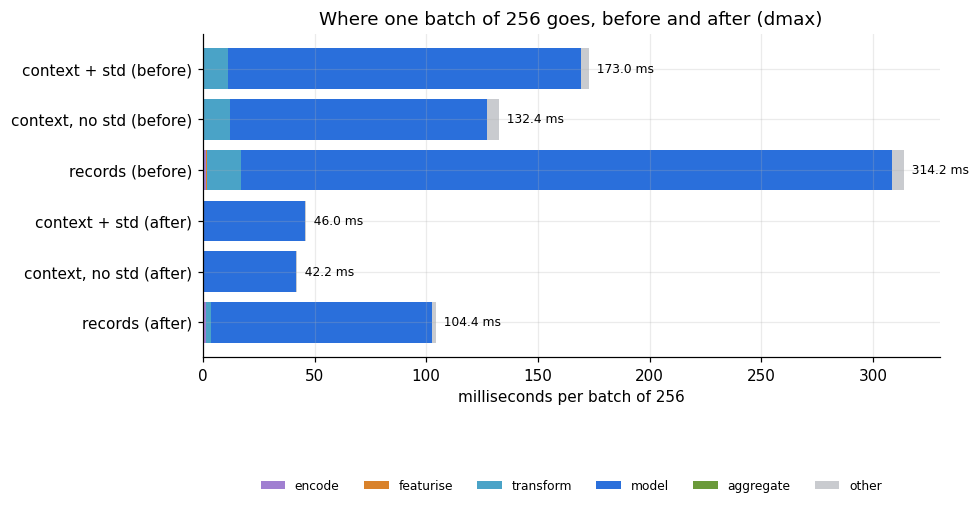

In [10]:
plot_breakdown({"before": base["breakdown"], "after": after["breakdown"]}, TASKS[0],
               "07_breakdown_before_after.png",
               f"Where one batch of 256 goes, before and after ({TASKS[0]})")

In [11]:
import cProfile
import pstats

ens_p = final[TASKS[0]]
ctx_p = ens_p.transform_context(record)
ens_p.predict(pool[:256], context=ctx_p)                          # warm
prof = cProfile.Profile()
prof.enable()
for _ in range(10):
    ens_p.predict(pool[:256], context=ctx_p, return_individual=False)
prof.disable()
rows = [{"function": f"{Path(f).name}:{line}({name})", "calls per batch": nc / 10,
         "own ms per batch": tt * 1e3 / 10, "cumulative ms per batch": ct * 1e3 / 10}
        for (f, line, name), (cc, nc, tt, ct, callers) in pstats.Stats(prof).stats.items()]
print(f"where the new code spends a batch of 256 ({TASKS[0]}, cached context, with std)")
display(pd.DataFrame(rows).sort_values("own ms per batch", ascending=False).head(12).round(2))

where the new code spends a batch of 256 (dmax, cached context, with std)


,function,calls per batch,own ms per batch,cumulative ms per batch
93,gp.py:161(_sq_dists),10.0,17.02,17.84
74,~:0(<built-in method torch._C._linalg.linalg_s...,5.0,13.53,13.53
81,gp.py:595(predict_in_context),5.0,5.85,48.04
61,~:0(<built-in method torch.exp>),30.0,5.51,5.51
99,ensemble.py:561(_folded_scores),5.0,4.79,52.83
90,gp.py:198(_rbf),10.0,3.16,14.36
13,~:0(<built-in method builtins.sum>),5.0,1.60,1.61
69,~:0(<method 'clamp_min' of 'torch._C.TensorBas...,15.0,0.74,0.74
72,~:0(<method 'sum' of 'torch._C.TensorBase' obj...,15.0,0.30,0.30
89,ensemble.py:448(predict),1.0,0.30,53.88


## 3. Twenty-five members

Five members is what `FusionEnsemble.fit` produces by default; the expected production size is
about 25. Inference cost depends on the member count, the training-set size and the block widths,
not on parameter values, so the fitted `dmax` members are **cloned** up to 25 (deep copies, so the
memory footprint is real). This measures cost only: a cloned member adds no accuracy.

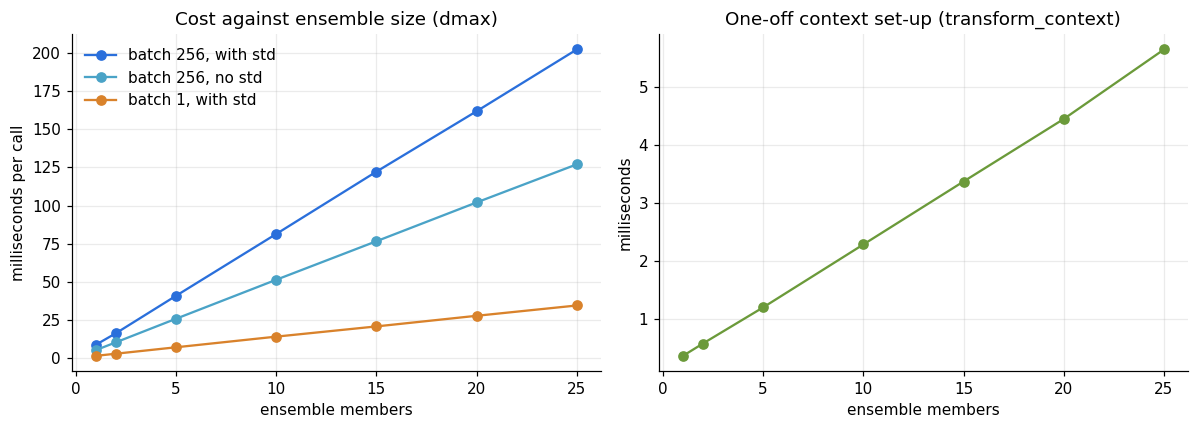

,members,setup_ms,batch256_std_ms,batch256_nostd_ms,batch1_std_ms
0,1,0.36,8.82,5.33,1.59
1,2,0.58,16.36,10.43,3.01
2,5,1.20,40.87,25.86,7.21
3,10,2.28,81.33,51.37,14.17
4,15,3.37,122.13,76.60,20.87
5,20,4.45,161.68,101.99,27.82
6,25,5.64,202.10,126.93,34.57


largest median/minimum ratio at batch 256: 1.11 (1.0 = no contention)
marginal cost of one more member at batch 256 with std: 8.1 ms (32 microseconds per molecule)


45584

In [12]:
source = final["dmax"] if "dmax" in final else next(iter(final.values()))
task_m = source.task
clones = [copy.deepcopy(source.members[i % len(source.members)]) for i in range(25)]
batch = pool[:256]
SIZES = (1, 2, 5, 10, 15, 20, 25)
ens_by_size, ctx_by_size = {}, {}
for m in SIZES:
    ens_by_size[m] = FusionEnsemble(clones[:m], data, task_m, shared_context=True)
    ctx_by_size[m] = ens_by_size[m].transform_context(record)
    ens_by_size[m].predict(batch, context=ctx_by_size[m])           # warm
calls = {
    "setup_ms": lambda m: ens_by_size[m].transform_context(record),
    "batch256_std_ms": lambda m: ens_by_size[m].predict(batch, context=ctx_by_size[m],
                                                        return_individual=False),
    "batch256_nostd_ms": lambda m: ens_by_size[m].predict(batch, context=ctx_by_size[m],
                                                          return_individual=False,
                                                          return_std=False),
    "batch1_std_ms": lambda m: ens_by_size[m].predict(batch[:1], context=ctx_by_size[m],
                                                      return_individual=False)}
# Interleaved rounds, minimum per cell: on a shared machine the minimum is the least contended
# estimate of a deterministic computation, and interleaving spreads any drift over every size.
samples = {(name, m): [] for name in calls for m in SIZES}
for _ in range(3 * REPEAT):
    for m in SIZES:
        for name, call in calls.items():
            t0 = time.perf_counter()
            call(m)
            samples[(name, m)].append(time.perf_counter() - t0)
members_frame = pd.DataFrame([
    {"members": m, **{name: min(samples[(name, m)]) * 1e3 for name in calls},
     **{f"{name}_median": float(np.median(samples[(name, m)])) * 1e3 for name in calls}}
    for m in SIZES])
members_frame.to_csv(RESULTS / "members_scaling.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for col, label, color in (("batch256_std_ms", "batch 256, with std", "#2a6fdb"),
                          ("batch256_nostd_ms", "batch 256, no std", "#4aa3c7"),
                          ("batch1_std_ms", "batch 1, with std", "#d9822b")):
    axes[0].plot(members_frame["members"], members_frame[col], marker="o", color=color,
                 label=label)
axes[0].set_xlabel("ensemble members")
axes[0].set_ylabel("milliseconds per call")
axes[0].set_title(f"Cost against ensemble size ({task_m})")
axes[0].legend(frameon=False)
axes[1].plot(members_frame["members"], members_frame["setup_ms"], marker="o", color="#6b9a3a")
axes[1].set_xlabel("ensemble members")
axes[1].set_ylabel("milliseconds")
axes[1].set_title("One-off context set-up (transform_context)")
fig.tight_layout()
fig.savefig(RESULTS / "08_members.png", dpi=130)
plt.show()
slope = np.polyfit(members_frame["members"], members_frame["batch256_std_ms"], 1)[0]
display(members_frame[['members', 'setup_ms', 'batch256_std_ms', 'batch256_nostd_ms', 'batch1_std_ms']].round(2))
noise = (members_frame['batch256_std_ms_median'] / members_frame['batch256_std_ms']).max()
print(f'largest median/minimum ratio at batch 256: {noise:.2f} (1.0 = no contention)')
print(f"marginal cost of one more member at batch 256 with std: {slope:.1f} ms "
      f"({slope / 256 * 1e3:.0f} microseconds per molecule)")
del clones
gc.collect()

## 4. What it cost in accuracy (reported, not gated)

Two views. First, how far each configuration's predictions move from the **unchanged code's** on
the same 256 molecules in one context, set against the spread of the baseline's own members.
Second, the score on the fold held out from fitting (the saved ensembles were fitted on the pool of
split 0 only), which says whether that movement is harmful.

movement of the predictions against the unchanged code (256 molecules, one context)


,task,config,corr,mean_abs_shift,max_abs_shift,baseline_member_spread,std_ratio
0,dmax,A,1.0000,0.0000,0.0000,0.0453,1.0000
1,dmax,B,0.9999,0.0132,0.0153,0.0453,1.0199
2,dmax,C,1.0000,0.0000,0.0001,0.0453,1.0000
3,dmax,D,0.9999,0.0132,0.0152,0.0453,1.0199
4,pdc50,A,1.0000,0.0000,0.0000,0.2351,1.0000
5,pdc50,B,1.0000,0.1855,0.1882,0.2351,1.0399
6,pdc50,C,1.0000,0.0036,0.0081,0.2351,0.9998
7,pdc50,D,1.0000,0.1820,0.1870,0.2351,1.0398
8,activity,A,1.0000,0.0000,0.0000,0.0444,1.0000
9,activity,B,0.9997,0.0147,0.0230,0.0444,1.0693


held-out score (R2, or ROC-AUC for activity): unchanged code, then configurations A-D


config,metric,before,A,B,C,D
task,,,,,,
activity,ROC-AUC,0.8946,0.8946,0.8883,0.8980,0.8919
dmax,R2,0.4258,0.4258,0.4271,0.4258,0.4271
pdc50,R2,0.5988,0.5988,0.5954,0.5984,0.5951


members whose float32 factorisation had to be promoted to float64


config,A,B,C,D
task,,,,
activity,0,0,0,0
dmax,0,0,0,0
pdc50,0,0,0,0


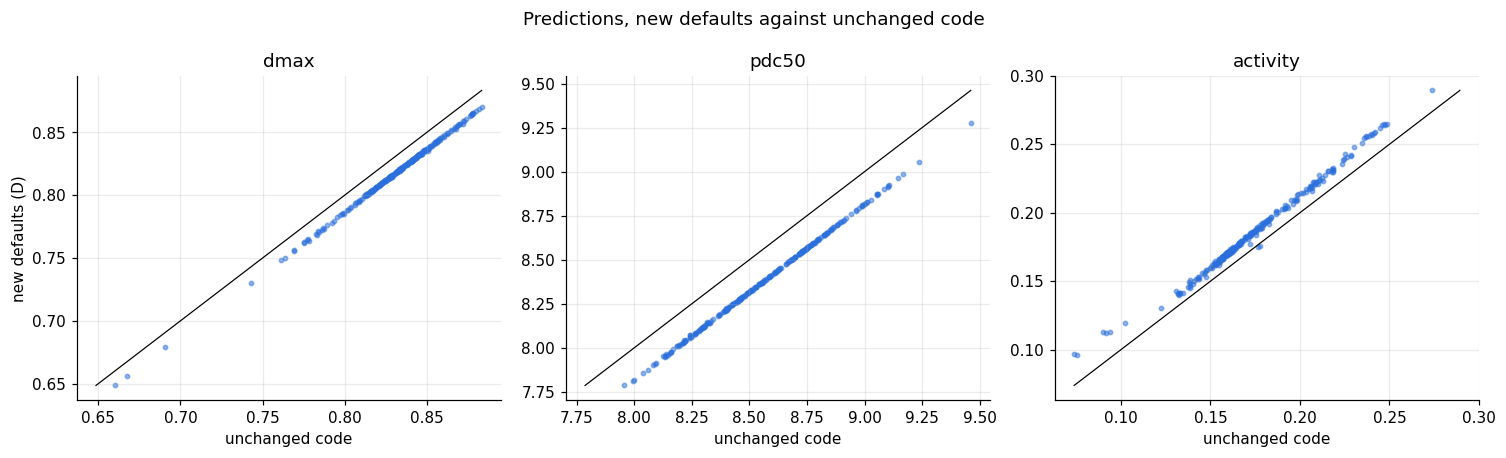

In [13]:
shift_frame = pd.DataFrame(shifts)
score_frame = pd.DataFrame(heldout).pivot(index="task", columns="config", values="score")
score_frame.insert(0, "before", base["heldout"].set_index("task")["score"])
metric = base["heldout"].set_index("task")["metric"]
score_frame.insert(0, "metric", metric)
shift_frame.to_csv(RESULTS / "accuracy_shift.csv", index=False)
score_frame.to_csv(RESULTS / "accuracy_heldout.csv")
print("movement of the predictions against the unchanged code (256 molecules, one context)")
display(shift_frame.round(4))
print("held-out score (R2, or ROC-AUC for activity): unchanged code, then configurations A-D")
display(score_frame.round(4))
print("members whose float32 factorisation had to be promoted to float64")
display(pd.DataFrame(promoted).pivot(index="task", columns="config", values="promoted_members"))

fig, axes = plt.subplots(1, len(TASKS), figsize=(4.6 * len(TASKS), 4.2), squeeze=False)
for ax, task in zip(axes[0], TASKS):
    b = base_pred[f"{task}_mean"]
    d = final[task].predict(pool[:256], context=final[task].transform_context(record)).mean
    ax.scatter(b, d, s=8, alpha=0.5, color="#2a6fdb")
    lo, hi = min(b.min(), d.min()), max(b.max(), d.max())
    ax.plot([lo, hi], [lo, hi], "k", lw=0.8)
    ax.set_title(task)
    ax.set_xlabel("unchanged code")
axes[0][0].set_ylabel("new defaults (D)")
fig.suptitle("Predictions, new defaults against unchanged code")
fig.tight_layout()
fig.savefig(RESULTS / "09_prediction_shift.png", dpi=130)
plt.show()

## 5. Conclusions

Generated from the numbers above, so they cannot drift from the measurements.

In [14]:
def speed(path, batch=256):
    s = speedups(batch).query("path == @path").set_index("task")["speedup"]
    return s.min(), s.max()


lo, hi = speed("context+std")
lo_n, hi_n = speed("context")
lo_r, hi_r = speed("records")
lo_m, hi_m = speed("matrix")
print("Speed (batch 256, against the unchanged code, across tasks)")
print(f"  - cached context, with std:  {lo:.1f}-{hi:.1f}x")
print(f"  - cached context, no std:    {lo_n:.1f}-{hi_n:.1f}x")
print(f"  - records path:              {lo_r:.1f}-{hi_r:.1f}x")
print(f"  - predict_matrix:            {lo_m:.1f}-{hi_m:.1f}x")

d256 = after["scaling"].query("batch == 256 and path == 'context+std'").set_index("task")
print("\nThroughput of the new defaults, cached context with std, batch 256")
for task in TASKS:
    print(f"  - {task}: {d256.loc[task, 'mol_per_s']:.0f} molecules/s "
          f"({d256.loc[task, 'us_per_mol']:.0f} microseconds each) with "
          f"{int(after['setup'].set_index('task').loc[task, 'members'])} members")

series = members_frame["batch256_std_ms"].to_numpy()
monotone = bool(np.all(series[1:] >= 0.9 * series[:-1]))
if not monotone:
    print("WARNING: cost is not monotone in the member count -> the machine was too busy for the "
          "member sweep; re-run it before quoting the numbers below")
per_member_us = slope / 256 * 1e3
five = members_frame.query("members == 5")["batch256_std_ms"].iloc[0]
twenty_five = members_frame.query("members == 25")["batch256_std_ms"].iloc[0]
print(f"\nEnsemble size ({task_m}): 5 members {five:.0f} ms, 25 members {twenty_five:.0f} ms "
      f"per 256 molecules, i.e. {twenty_five / five:.1f}x for 5x the members; "
      f"+{per_member_us:.0f} microseconds per molecule per extra member")

feat = base["featurise"].iloc[0, 0] * 1e3
print(f"\nFeaturising a molecule that has never been seen costs {feat:.1f} ms, against "
      f"{d256['us_per_mol'].min() / 1e3:.2f}-{d256['us_per_mol'].max() / 1e3:.2f} ms to score it: "
      "for novel molecules the featuriser, not the model, is the bottleneck, and the memo cache "
      "only helps molecules proposed twice.")

cfg = (sweeps.query("batch == 256 and path == 'context+std'")
       .pivot(index="task", columns="config", values="us_per_mol").reindex(TASKS))
cfg.insert(0, "before", base["scaling"].query("batch == 256 and path == 'context+std'")
           .set_index("task")["us_per_mol"])


def span(ratio):
    return f"{ratio.min():.2f}-{ratio.max():.2f}x"


print("\nWhere the speed came from (cached context with std, batch 256, across tasks)")
print(f"  - removing the redundancies alone, still float64 (A against before): {span(cfg['before'] / cfg['A'])}")
print(f"  - float32 (C against A):                                              {span(cfg['A'] / cfg['C'])}")
print(f"  - shared context (B against A, and D against C):                      "
      f"{span(cfg['A'] / cfg['B'])} and {span(cfg['C'] / cfg['D'])}")
exact = shift_frame.query("config == 'A'")["max_abs_shift"].max()
print(f"  - configuration A reproduces the unchanged code's predictions to a maximum difference of {exact:.1e}")

twice = (after["scaling"].query("batch == 256 and path == 'context+std'").set_index("task")["us_per_mol"]
         / sweeps.query("batch == 256 and path == 'context+std' and config == 'D'")
         .set_index("task")["us_per_mol"]).reindex(TASKS)
print(f"\nMeasurement noise: this machine is shared (load average {os.getloadavg()[0]:.1f} on "
      f"{os.cpu_count()} cores). The same configuration (D) timed twice in this notebook differs by up "
      f"to {abs(twice - 1).max():.0%}, so read the speedups above as roughly +-30%, and the ordering "
      "of the small effects (redundancy removal, shared context) as unresolved.")

worst = shift_frame.query("config == 'D'").set_index("task")
print("\nAccuracy (new defaults against the unchanged code; reported, not gated)")
for task in TASKS:
    before_score, after_score = score_frame.loc[task, "before"], score_frame.loc[task, "D"]
    print(f"  - {task}: held-out {score_frame.loc[task, 'metric']} {before_score:.3f} -> "
          f"{after_score:.3f}; predictions correlate {worst.loc[task, 'corr']:.4f}, mean shift "
          f"{worst.loc[task, 'mean_abs_shift']:.4f} against a member spread of "
          f"{worst.loc[task, 'baseline_member_spread']:.4f}")
print("\nThe saved ensembles were fitted with standardised context and float64; they are served "
      "here under different numerics, so these scores understate what a refit would give.")

Speed (batch 256, against the unchanged code, across tasks)
  - cached context, with std:  2.8-4.3x
  - cached context, no std:    3.2-3.9x
  - records path:              2.3-2.6x
  - predict_matrix:            2.4-3.0x

Throughput of the new defaults, cached context with std, batch 256
  - dmax: 5601 molecules/s (179 microseconds each) with 5 members
  - pdc50: 2167 molecules/s (461 microseconds each) with 5 members
  - activity: 5146 molecules/s (194 microseconds each) with 5 members

Ensemble size (dmax): 5 members 41 ms, 25 members 202 ms per 256 molecules, i.e. 4.9x for 5x the members; +32 microseconds per molecule per extra member

Featurising a molecule that has never been seen costs 22.5 ms, against 0.18-0.46 ms to score it: for novel molecules the featuriser, not the model, is the bottleneck, and the memo cache only helps molecules proposed twice.

Where the speed came from (cached context with std, batch 256, across tasks)
  - removing the redundancies alone, still float64 (A